## 1. Importar Librerías

In [4]:
# Data manipulation
import pandas as pd
import numpy as np
import os
import json
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    make_scorer
)

# Imbalanced data handling
from imblearn.over_sampling import SMOTE

# Hyperparameter tuning
import optuna
from optuna.samplers import TPESampler
from optuna.visualization import plot_optimization_history, plot_param_importances

# Model persistence
import joblib

# Configuration
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(" Librerías importadas correctamente")
print(f" Fecha de tuning: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

 Librerías importadas correctamente
 Fecha de tuning: 2025-12-02 23:32:20


## 2. Cargar Datos Procesados

In [5]:
# Cargar dataset de productos con target
df = pd.read_csv('data/products_with_target.csv')

print(f" Dataset de Productos cargado")
print(f"   - Shape: {df.shape}")
print(f"   - Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n Distribución del target (is_successful):")
print(df['is_successful'].value_counts())
print(f"\n   Balance:")
print(df['is_successful'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))

 Dataset de Productos cargado
   - Shape: (8494, 28)
   - Memoria: 13.02 MB

 Distribución del target (is_successful):
is_successful
0    6825
1    1669
Name: count, dtype: int64

   Balance:
is_successful
0    80.4%
1    19.6%
Name: proportion, dtype: object


## 3. Ingeniería de Características

In [6]:
def create_features(df):
    """
    Crea features adicionales para mejorar el modelo
    Solo usa características de PRODUCTOS (sin reviews)
    """
    df_feat = df.copy()
    
    print(" Creando features avanzadas...\n")
    
    print(" Features de Precio...")
    
    # Has discount
    df_feat['has_sale'] = df_feat['sale_price_usd'].notna().astype(int)
    df_feat['has_value_price'] = df_feat['value_price_usd'].notna().astype(int)
    
    # Discount percentage
    df_feat['discount_pct'] = np.where(
        (df_feat['sale_price_usd'].notna()) & (df_feat['price_usd'] > 0),
        ((df_feat['price_usd'] - df_feat['sale_price_usd']) / df_feat['price_usd']) * 100,
        0
    )
    
    # Price range categories
    df_feat['price_range'] = pd.cut(
        df_feat['price_usd'], 
        bins=[0, 25, 50, 100, np.inf],
        labels=['low', 'medium', 'high', 'premium']
    )
    
    print("  Features de Marca...")
    
    # Brand popularity (number of products per brand)
    brand_counts = df_feat['brand_name'].value_counts()
    df_feat['brand_product_count'] = df_feat['brand_name'].map(brand_counts)
    
    # Brand average rating
    brand_avg_rating = df_feat.groupby('brand_name')['rating'].mean()
    df_feat['brand_avg_rating'] = df_feat['brand_name'].map(brand_avg_rating)
    
    # Brand average loves
    brand_avg_loves = df_feat.groupby('brand_name')['loves_count'].mean()
    df_feat['brand_avg_loves'] = df_feat['brand_name'].map(brand_avg_loves)
    
    # Is top brand (top 20 by product count)
    top_brands = brand_counts.head(20).index
    df_feat['is_top_brand'] = df_feat['brand_name'].isin(top_brands).astype(int)
    
    print(" Features de Producto...")
    
    # Has variations
    df_feat['has_variations'] = (df_feat['child_count'] > 0).astype(int)
    
    # Variation price range
    df_feat['variation_price_range'] = np.where(
        (df_feat['child_max_price'].notna()) & (df_feat['child_min_price'].notna()),
        df_feat['child_max_price'] - df_feat['child_min_price'],
        0
    )
    
    # Has ingredients
    df_feat['has_ingredients'] = df_feat['ingredients'].notna().astype(int)
    
    # Has highlights
    df_feat['has_highlights'] = df_feat['highlights'].notna().astype(int)
    
    # Number of highlights
    df_feat['num_highlights'] = df_feat['highlights'].apply(
        lambda x: len(str(x).split(',')) if pd.notna(x) else 0
    )
    
    print(" Features de Exclusividad...")
    
    # Exclusivity score (weighted sum)
    df_feat['exclusivity_score'] = (
        df_feat['sephora_exclusive'].fillna(0) * 3 +
        df_feat['limited_edition'].fillna(0) * 2 +
        df_feat['online_only'].fillna(0) * 1
    )
    
    # Is exclusive product (any type)
    df_feat['is_exclusive'] = (
        (df_feat['sephora_exclusive'] == 1) | 
        (df_feat['limited_edition'] == 1)
    ).astype(int)
    
    print(" Features de Categoría...")
    
    # Category depth (how many levels defined)
    df_feat['category_depth'] = (
        df_feat['primary_category'].notna().astype(int) +
        df_feat['secondary_category'].notna().astype(int) +
        df_feat['tertiary_category'].notna().astype(int)
    )
    
    print("\n Features creadas exitosamente")
    print(f"   - Features originales: {df.shape[1]}")
    print(f"   - Features totales: {df_feat.shape[1]}")
    print(f"   - Features nuevas: {df_feat.shape[1] - df.shape[1]}")
    
    return df_feat

# Crear features
df_features = create_features(df)

 Creando features avanzadas...

 Features de Precio...
  Features de Marca...
 Features de Producto...
 Features de Exclusividad...
 Features de Categoría...

 Features creadas exitosamente
   - Features originales: 28
   - Features totales: 44
   - Features nuevas: 16


## 4. Selección y Preparación de Features

In [7]:
# Seleccionar features para el modelo (27 features totales)

features_to_use = [
    # Basic product features (3)
    'price_usd', 'rating', 'child_count',
    
    # Binary flags (5)
    'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive',
    
    # Price features (3)
    'has_sale', 'has_value_price', 'discount_pct',
    
    # Brand features (4)
    'brand_product_count', 'brand_avg_rating', 'brand_avg_loves', 'is_top_brand',
    
    # Product features (5)
    'has_variations', 'variation_price_range', 'has_ingredients', 'has_highlights', 'num_highlights',
    
    # Exclusivity features (2)
    'exclusivity_score', 'is_exclusive',
    
    # Category features (1)
    'category_depth'
]

print(f" Features seleccionadas: {len(features_to_use)}")
print(f"\n Solo características del PRODUCTO")
print(f"   Total: {len(features_to_use)} features")

# Preparar X y y
X = df_features[features_to_use].copy()
y = df_features['is_successful'].copy()

# Imputar valores nulos
print("\n Imputando valores nulos...")
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"\n Datos preparados:")
print(f"   - X shape: {X_imputed.shape}")
print(f"   - y shape: {y.shape}")
print(f"   - Valores nulos en X: {X_imputed.isnull().sum().sum()}")

 Features seleccionadas: 23

 Solo características del PRODUCTO
   Total: 23 features

 Imputando valores nulos...

 Datos preparados:
   - X shape: (8494, 23)
   - y shape: (8494,)
   - Valores nulos en X: 0


## 5. División de Datos y SMOTE

In [8]:
# Split train/test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y
)

print(" División de datos:")
print(f"\n   Train set: {X_train.shape}")
print(f"   Test set:  {X_test.shape}")

# Aplicar SMOTE
print("\n  Aplicando SMOTE para balancear clases...")
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\n Datos balanceados con SMOTE:")
print(f"   - Train shape: {X_train_balanced.shape}")
print(f"   - Clase 0: {(y_train_balanced == 0).sum()}")
print(f"   - Clase 1: {(y_train_balanced == 1).sum()}")

 División de datos:

   Train set: (6795, 23)
   Test set:  (1699, 23)

  Aplicando SMOTE para balancear clases...

 Datos balanceados con SMOTE:
   - Train shape: (10920, 23)
   - Clase 0: 5460
   - Clase 1: 5460


## 6. Preparar Datos para Optimización

Usaremos el **dataset completo balanceado** para la optimización (mejores resultados).

In [9]:
# Usar dataset completo balanceado para tuning (mejores resultados)
X_sample = X_train_balanced.copy()
y_sample = y_train_balanced.copy()

print(f" Dataset para tuning:")
print(f"   - Sample size: {len(X_sample):,} (Dataset completo)")
print(f"   - Clase 0: {(y_sample == 0).sum()}")
print(f"   - Clase 1: {(y_sample == 1).sum()}")
print(f"\n Usando TODOS los datos balanceados para mejor optimización")

 Dataset para tuning:
   - Sample size: 10,920 (Dataset completo)
   - Clase 0: 5460
   - Clase 1: 5460

 Usando TODOS los datos balanceados para mejor optimización


## 7. Optimización con Optuna

### 7.1 XGBoost

In [10]:
def objective_xgboost(trial):
    """
    Función objetivo para optimizar XGBoost
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': RANDOM_STATE,
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'n_jobs': -1
    }
    
    # Modelo
    model = xgb.XGBClassifier(**params)
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    f1_scores = cross_val_score(model, X_sample, y_sample, cv=cv, scoring='f1', n_jobs=-1)
    
    return f1_scores.mean()

# Crear estudio de Optuna
print(" Iniciando optimización de XGBoost...")
print(f"   - Trials: 100")
print(f"   - Sampler: TPE")
print(f"   - CV: 5-fold Stratified")
print(f"   - Métrica: F1-Score\n")

study_xgb = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='xgboost_optimization'
)

study_xgb.optimize(objective_xgboost, n_trials=100, show_progress_bar=True)

print("\n Optimización de XGBoost completada")
print(f"   - Mejor F1-Score: {study_xgb.best_value:.4f}")
print(f"   - Mejores hiperparámetros:")
for key, value in study_xgb.best_params.items():
    print(f"      {key}: {value}")

[I 2025-12-02 23:32:23,660] A new study created in memory with name: xgboost_optimization


 Iniciando optimización de XGBoost...
   - Trials: 100
   - Sampler: TPE
   - CV: 5-fold Stratified
   - Métrica: F1-Score



Best trial: 0. Best value: 0.922154:   1%|          | 1/100 [00:05<08:36,  5.22s/it]

[I 2025-12-02 23:32:28,879] Trial 0 finished with value: 0.9221543127067738 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.02904180608409973, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 0.6011150117432088}. Best is trial 0 with value: 0.9221543127067738.


Best trial: 0. Best value: 0.922154:   2%|▏         | 2/100 [00:08<06:32,  4.00s/it]

...

[I 2025-12-02 23:34:22,548] Trial 97 finished with value: 0.9234978012607442 and parameters: {'n_estimators': 394, 'max_depth': 8, 'learning_rate': 0.04916903523394826, 'subsample': 0.8885532483486446, 'colsample_bytree': 0.6913577092336194, 'min_child_weight': 3, 'gamma': 0.4503398742543506, 'reg_alpha': 0.8297471354118664, 'reg_lambda': 0.7927134515506193}. Best is trial 72 with value: 0.9250154980047001.


Best trial: 72. Best value: 0.925015:  99%|█████████▉| 99/100 [02:00<00:01,  1.24s/it]

[I 2025-12-02 23:34:23,837] Trial 98 finished with value: 0.9227576766835845 and parameters: {'n_estimators': 490, 'max_depth': 7, 'learning_rate': 0.040864319427709336, 'subsample': 0.961598055229394, 'colsample_bytree': 0.7102890699463189, 'min_child_weight': 5, 'gamma': 0.41429249562172754, 'reg_alpha': 0.7743605929701125, 'reg_lambda': 0.05584745143796483}. Best is trial 72 with value: 0.9250154980047001.


Best trial: 72. Best value: 0.925015: 100%|██████████| 100/100 [02:01<00:00,  1.21s/it]

[I 2025-12-02 23:34:25,097] Trial 99 finished with value: 0.9240954053472443 and parameters: {'n_estimators': 440, 'max_depth': 7, 'learning_rate': 0.05441298105058246, 'subsample': 0.9450445311876368, 'colsample_bytree': 0.6623605119441924, 'min_child_weight': 2, 'gamma': 0.4308361374387152, 'reg_alpha': 0.9284289355449881, 'reg_lambda': 0.11169014986274439}. Best is trial 72 with value: 0.9250154980047001.

 Optimización de XGBoost completada
   - Mejor F1-Score: 0.9250
   - Mejores hiperparámetros:
      n_estimators: 484
      max_depth: 8
      learning_rate: 0.0449209982286488
      subsample: 0.9162046753049063
      colsample_bytree: 0.6113582224290375
      min_child_weight: 1
      gamma: 0.4664576857790823
      reg_alpha: 0.9715139341508138
      reg_lambda: 0.2994392099392803


### 7.2 LightGBM

In [11]:
def objective_lightgbm(trial):
    """
    Función objetivo para optimizar LightGBM
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': RANDOM_STATE,
        'verbose': -1,
        'n_jobs': -1
    }
    
    # Modelo
    model = lgb.LGBMClassifier(**params)
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    f1_scores = cross_val_score(model, X_sample, y_sample, cv=cv, scoring='f1', n_jobs=-1)
    
    return f1_scores.mean()

# Crear estudio de Optuna
print("\n Iniciando optimización de LightGBM...")
print(f"   - Trials: 100")
print(f"   - Sampler: TPE")
print(f"   - CV: 5-fold Stratified")
print(f"   - Métrica: F1-Score\n")

study_lgb = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='lightgbm_optimization'
)

study_lgb.optimize(objective_lightgbm, n_trials=100, show_progress_bar=True)

print("\n Optimización de LightGBM completada")
print(f"   - Mejor F1-Score: {study_lgb.best_value:.4f}")
print(f"   - Mejores hiperparámetros:")
for key, value in study_lgb.best_params.items():
    print(f"      {key}: {value}")

[I 2025-12-02 23:34:25,112] A new study created in memory with name: lightgbm_optimization



 Iniciando optimización de LightGBM...
   - Trials: 100
   - Sampler: TPE
   - CV: 5-fold Stratified
   - Métrica: F1-Score



Best trial: 0. Best value: 0.92214:   1%|          | 1/100 [00:03<05:39,  3.43s/it]

[I 2025-12-02 23:34:28,544] Trial 0 finished with value: 0.9221403982299361 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'num_leaves': 98, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'min_child_samples': 10, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 0.6011150117432088}. Best is trial 0 with value: 0.9221403982299361.


Best trial: 0. Best value: 0.92214:   2%|▏         | 2/100 [00:04<03:34,  2.19s/it]

...

[I 2025-12-02 23:39:43,355] Trial 97 finished with value: 0.9223968479481683 and parameters: {'n_estimators': 376, 'max_depth': 9, 'learning_rate': 0.030542400256352437, 'num_leaves': 124, 'subsample': 0.6232760403187448, 'colsample_bytree': 0.7620088466301852, 'min_child_samples': 7, 'reg_alpha': 0.6301484548774422, 'reg_lambda': 0.885822653066439}. Best is trial 87 with value: 0.9247269840265459.


Best trial: 87. Best value: 0.924727:  99%|█████████▉| 99/100 [05:20<00:03,  3.15s/it]

[I 2025-12-02 23:39:46,074] Trial 98 finished with value: 0.9225750112656914 and parameters: {'n_estimators': 352, 'max_depth': 9, 'learning_rate': 0.03699920911174862, 'num_leaves': 147, 'subsample': 0.6346495221048104, 'colsample_bytree': 0.7100137428842658, 'min_child_samples': 12, 'reg_alpha': 0.7157799323941723, 'reg_lambda': 0.9548777054528156}. Best is trial 87 with value: 0.9247269840265459.


Best trial: 87. Best value: 0.924727: 100%|██████████| 100/100 [05:23<00:00,  3.24s/it]

[I 2025-12-02 23:39:48,848] Trial 99 finished with value: 0.9228784512890096 and parameters: {'n_estimators': 385, 'max_depth': 8, 'learning_rate': 0.03469918129588189, 'num_leaves': 135, 'subsample': 0.6124448325371398, 'colsample_bytree': 0.7417593460975439, 'min_child_samples': 5, 'reg_alpha': 0.5440431020682895, 'reg_lambda': 0.9273935661992057}. Best is trial 87 with value: 0.9247269840265459.

 Optimización de LightGBM completada
   - Mejor F1-Score: 0.9247
   - Mejores hiperparámetros:
      n_estimators: 373
      max_depth: 9
      learning_rate: 0.03700447364852221
      num_leaves: 124
      subsample: 0.6289506277247345
      colsample_bytree: 0.7382504722102488
      min_child_samples: 7
      reg_alpha: 0.5266597440705636
      reg_lambda: 0.8499654593521022


### 7.3 Random Forest

In [12]:
def objective_randomforest(trial):
    """
    Función objetivo para optimizar Random Forest
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }
    
    # Modelo
    model = RandomForestClassifier(**params)
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    f1_scores = cross_val_score(model, X_sample, y_sample, cv=cv, scoring='f1', n_jobs=-1)
    
    return f1_scores.mean()

# Crear estudio de Optuna
print("\n Iniciando optimización de Random Forest...")
print(f"   - Trials: 100")
print(f"   - Sampler: TPE")
print(f"   - CV: 5-fold Stratified")
print(f"   - Métrica: F1-Score\n")

study_rf = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='randomforest_optimization'
)

study_rf.optimize(objective_randomforest, n_trials=100, show_progress_bar=True)

print("\n Optimización de Random Forest completada")
print(f"   - Mejor F1-Score: {study_rf.best_value:.4f}")
print(f"   - Mejores hiperparámetros:")
for key, value in study_rf.best_params.items():
    print(f"      {key}: {value}")

[I 2025-12-02 23:39:48,870] A new study created in memory with name: randomforest_optimization



 Iniciando optimización de Random Forest...
   - Trials: 100
   - Sampler: TPE
   - CV: 5-fold Stratified
   - Métrica: F1-Score



Best trial: 0. Best value: 0.917092:   1%|          | 1/100 [00:01<02:33,  1.55s/it]

[I 2025-12-02 23:39:50,424] Trial 0 finished with value: 0.9170916189133 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.9170916189133.


Best trial: 0. Best value: 0.917092:   2%|▏         | 2/100 [00:03<02:48,  1.72s/it]

...

[I 2025-12-02 23:42:27,753] Trial 97 finished with value: 0.9243687747525927 and parameters: {'n_estimators': 359, 'max_depth': 30, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True}. Best is trial 37 with value: 0.9247501335031444.


Best trial: 37. Best value: 0.92475:  99%|█████████▉| 99/100 [02:40<00:01,  1.68s/it]

[I 2025-12-02 23:42:29,439] Trial 98 finished with value: 0.9242307930670342 and parameters: {'n_estimators': 357, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True}. Best is trial 37 with value: 0.9247501335031444.


Best trial: 37. Best value: 0.92475: 100%|██████████| 100/100 [02:42<00:00,  1.62s/it]

[I 2025-12-02 23:42:31,335] Trial 99 finished with value: 0.9239437144485381 and parameters: {'n_estimators': 338, 'max_depth': 30, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False}. Best is trial 37 with value: 0.9247501335031444.

 Optimización de Random Forest completada
   - Mejor F1-Score: 0.9248
   - Mejores hiperparámetros:
      n_estimators: 380
      max_depth: 25
      min_samples_split: 3
      min_samples_leaf: 1
      max_features: log2
      bootstrap: True


## 8. Comparación de Resultados de Optimización

In [13]:
# Crear DataFrame con resultados
optimization_results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'Random Forest'],
    'Best F1-Score (CV)': [
        study_xgb.best_value,
        study_lgb.best_value,
        study_rf.best_value
    ],
    'N_Trials': [
        len(study_xgb.trials),
        len(study_lgb.trials),
        len(study_rf.trials)
    ]
}).sort_values('Best F1-Score (CV)', ascending=False)

print("COMPARACIÓN DE OPTIMIZACIÓN \n")
print(optimization_results.to_string(index=False))

best_model_opt = optimization_results.iloc[0]['Model']
print(f"\nMejor modelo en optimización: {best_model_opt}")
print(f"   F1-Score (CV): {optimization_results.iloc[0]['Best F1-Score (CV)']:.4f}")

COMPARACIÓN DE OPTIMIZACIÓN 

        Model  Best F1-Score (CV)  N_Trials
      XGBoost              0.9250       100
Random Forest              0.9248       100
     LightGBM              0.9247       100

Mejor modelo en optimización: XGBoost
   F1-Score (CV): 0.9250


## 9. Entrenamiento con Hiperparámetros Optimizados

Entrenar modelos con los mejores hiperparámetros en el dataset completo balanceado.

In [14]:
print("Entrenando modelos con hiperparámetros optimizados...\n")

# XGBoost optimizado
print(" XGBoost...")
xgb_tuned = xgb.XGBClassifier(**study_xgb.best_params)
xgb_tuned.fit(X_train_balanced, y_train_balanced)
xgb_pred = xgb_tuned.predict(X_test)
xgb_proba = xgb_tuned.predict_proba(X_test)[:, 1]

xgb_metrics = {
    'Model': 'XGBoost (Tuned)',
    'Accuracy': accuracy_score(y_test, xgb_pred),
    'Precision': precision_score(y_test, xgb_pred),
    'Recall': recall_score(y_test, xgb_pred),
    'F1-Score': f1_score(y_test, xgb_pred),
    'ROC-AUC': roc_auc_score(y_test, xgb_proba)
}

print(f"    Completado - F1: {xgb_metrics['F1-Score']:.4f}")

# LightGBM optimizado
print("\n LightGBM...")
lgb_tuned = lgb.LGBMClassifier(**study_lgb.best_params)
lgb_tuned.fit(X_train_balanced, y_train_balanced)
lgb_pred = lgb_tuned.predict(X_test)
lgb_proba = lgb_tuned.predict_proba(X_test)[:, 1]

lgb_metrics = {
    'Model': 'LightGBM (Tuned)',
    'Accuracy': accuracy_score(y_test, lgb_pred),
    'Precision': precision_score(y_test, lgb_pred),
    'Recall': recall_score(y_test, lgb_pred),
    'F1-Score': f1_score(y_test, lgb_pred),
    'ROC-AUC': roc_auc_score(y_test, lgb_proba)
}

print(f"    Completado - F1: {lgb_metrics['F1-Score']:.4f}")

# Random Forest optimizado
print("\n Random Forest...")
rf_tuned = RandomForestClassifier(**study_rf.best_params)
rf_tuned.fit(X_train_balanced, y_train_balanced)
rf_pred = rf_tuned.predict(X_test)
rf_proba = rf_tuned.predict_proba(X_test)[:, 1]

rf_metrics = {
    'Model': 'Random Forest (Tuned)',
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'F1-Score': f1_score(y_test, rf_pred),
    'ROC-AUC': roc_auc_score(y_test, rf_proba)
}

print(f"    Completado - F1: {rf_metrics['F1-Score']:.4f}")

# DataFrame de resultados
tuned_metrics = pd.DataFrame([xgb_metrics, lgb_metrics, rf_metrics])
tuned_metrics = tuned_metrics.sort_values('F1-Score', ascending=False)

print("\n" + "="*80)
print(" RESULTADOS EN TEST SET")
print("="*80 + "\n")
print(tuned_metrics.to_string(index=False))

Entrenando modelos con hiperparámetros optimizados...

 XGBoost...
    Completado - F1: 0.6863

 LightGBM...
[LightGBM] [Info] Number of positive: 5460, number of negative: 5460
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000600 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4410
[LightGBM] [Info] Number of data points in the train set: 10920, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

## 10. Cargar Métricas Baseline para Comparación

In [15]:
# Cargar métricas baseline del notebook anterior
try:
    baseline_metrics = pd.read_csv('results/baseline_metrics.csv', index_col=0)
    
    print(" Comparación: Baseline vs Tuned\n")
    print("="*80)
    print("BASELINE MODELS:")
    print("="*80)
    print(baseline_metrics[['test_accuracy', 'precision', 'recall', 'f1', 'roc_auc']].to_string())
    
    print("\n" + "="*80)
    print("TUNED MODELS:")
    print("="*80)
    print(tuned_metrics[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].to_string(index=False))
    
    # Mejora en F1-Score
    print("\n MEJORA EN F1-SCORE:")
    for model_name in ['XGBoost', 'LightGBM', 'Random Forest']:
        if model_name in baseline_metrics.index:
            baseline_f1 = baseline_metrics.loc[model_name, 'f1']
            tuned_f1 = tuned_metrics[tuned_metrics['Model'].str.contains(model_name)]['F1-Score'].values[0]
            improvement = ((tuned_f1 - baseline_f1) / baseline_f1) * 100
            print(f"   {model_name}: {baseline_f1:.4f} → {tuned_f1:.4f} ({improvement:+.2f}%)")
            
except FileNotFoundError:
    print("  Archivo baseline_metrics.csv no encontrado")
    print("   Ejecuta el notebook 02_Model_Training_and_Evaluation.ipynb primero")

 Comparación: Baseline vs Tuned

BASELINE MODELS:
               test_accuracy  precision  recall     f1  roc_auc
Random Forest         0.8593     0.6134  0.7695 0.6826   0.9240
XGBoost               0.8705     0.6541  0.7246 0.6875   0.9335
LightGBM              0.8782     0.6730  0.7395 0.7047   0.9332

TUNED MODELS:
                Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
     LightGBM (Tuned)    0.8782     0.6862  0.7006    0.6933   0.9325
      XGBoost (Tuned)    0.8746     0.6754  0.6976    0.6863   0.9341
Random Forest (Tuned)    0.8788     0.6988  0.6737    0.6860   0.9282

 MEJORA EN F1-SCORE:
   XGBoost: 0.6875 → 0.6863 (-0.17%)
   LightGBM: 0.7047 → 0.6933 (-1.61%)
   Random Forest: 0.6826 → 0.6860 (+0.49%)


## 11. Visualizaciones

### 11.1 Historia de Optimización

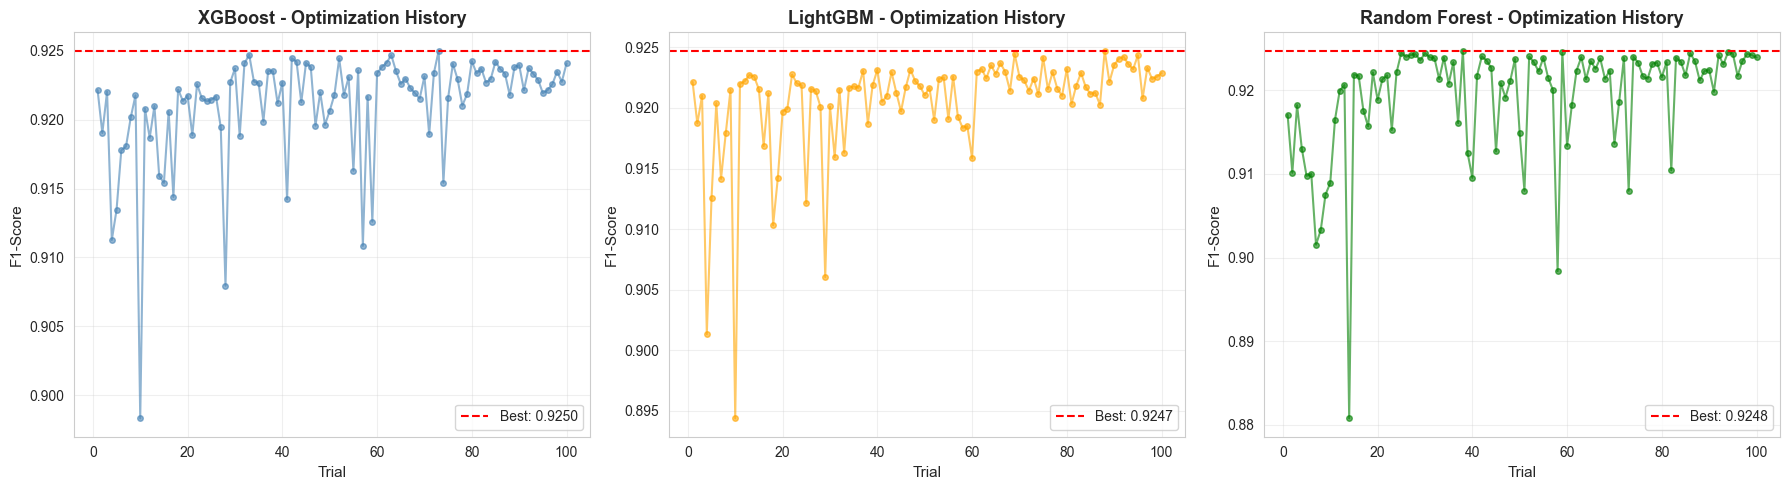

 Historia de optimización guardada: results/optimization_history.png


In [16]:
# Gráficos de historia de optimización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

studies = [
    (study_xgb, 'XGBoost', 'steelblue'),
    (study_lgb, 'LightGBM', 'orange'),
    (study_rf, 'Random Forest', 'green')
]

for idx, (study, name, color) in enumerate(studies):
    ax = axes[idx]
    
    # Extraer valores
    trials = study.trials
    values = [trial.value for trial in trials if trial.value is not None]
    trial_numbers = list(range(1, len(values) + 1))
    
    # Plot
    ax.plot(trial_numbers, values, 'o-', color=color, alpha=0.6, markersize=4)
    ax.axhline(y=study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.4f}')
    
    ax.set_xlabel('Trial', fontsize=11)
    ax.set_ylabel('F1-Score', fontsize=11)
    ax.set_title(f'{name} - Optimization History', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/optimization_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Historia de optimización guardada: results/optimization_history.png")

### 11.2 Importancia de Hiperparámetros

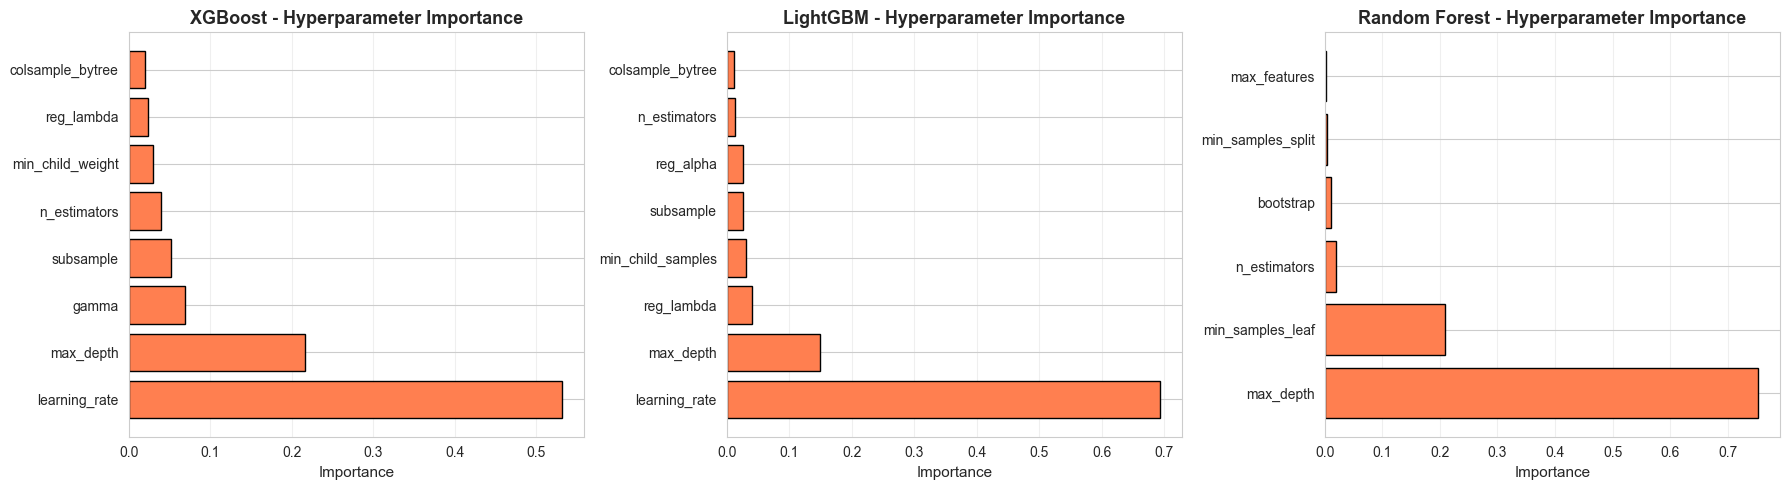

 Importancia de hiperparámetros guardada: results/hyperparameter_importance.png


In [17]:
# Importancia de hiperparámetros
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (study, name) in enumerate([(study_xgb, 'XGBoost'), 
                                      (study_lgb, 'LightGBM'), 
                                      (study_rf, 'Random Forest')]):
    ax = axes[idx]
    
    # Calcular importancia
    importances = optuna.importance.get_param_importances(study)
    
    # Ordenar y seleccionar top 8
    sorted_importances = sorted(importances.items(), key=lambda x: x[1], reverse=True)[:8]
    params, values = zip(*sorted_importances)
    
    # Plot
    y_pos = np.arange(len(params))
    ax.barh(y_pos, values, color='coral', edgecolor='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(params)
    ax.set_xlabel('Importance', fontsize=11)
    ax.set_title(f'{name} - Hyperparameter Importance', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('results/hyperparameter_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Importancia de hiperparámetros guardada: results/hyperparameter_importance.png")

### 11.3 Matrices de Confusión

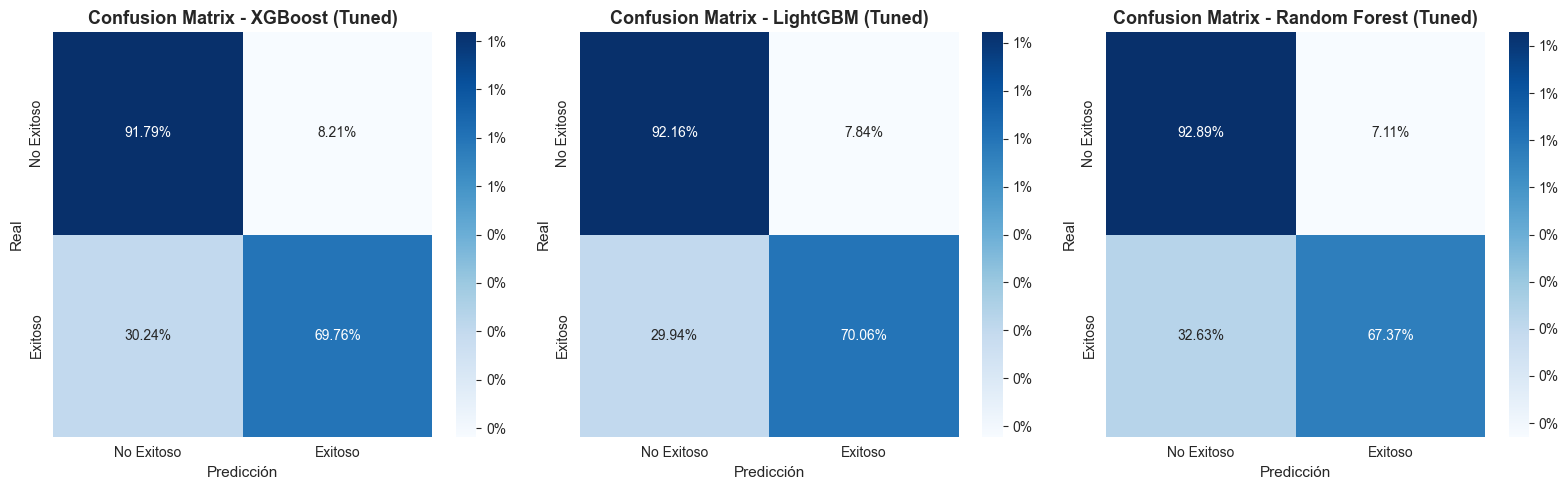

 Matrices de confusión guardadas: results/confusion_matrices_tuned.png


In [18]:
# Matrices de confusión para modelos optimizados
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

predictions_tuned = [
    (xgb_pred, 'XGBoost (Tuned)'),
    (lgb_pred, 'LightGBM (Tuned)'),
    (rf_pred, 'Random Forest (Tuned)')
]

for idx, (pred, name) in enumerate(predictions_tuned):
    cm = confusion_matrix(y_test, pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['No Exitoso', 'Exitoso'],
                yticklabels=['No Exitoso', 'Exitoso'],
                ax=axes[idx], cbar_kws={'format': '%.0f%%'})
    
    axes[idx].set_title(f'Confusion Matrix - {name}', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Real', fontsize=11)
    axes[idx].set_xlabel('Predicción', fontsize=11)

plt.tight_layout()
plt.savefig('results/confusion_matrices_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Matrices de confusión guardadas: results/confusion_matrices_tuned.png")

## 12. Guardar Modelos y Resultados

In [19]:
# Crear directorios
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

print(" Guardando modelos y resultados...\n")

# Guardar modelos optimizados
joblib.dump(xgb_tuned, 'models/xgboost_tuned.pkl')
print("    XGBoost guardado: models/xgboost_tuned.pkl")

joblib.dump(lgb_tuned, 'models/lightgbm_tuned.pkl')
print("    LightGBM guardado: models/lightgbm_tuned.pkl")

joblib.dump(rf_tuned, 'models/randomforest_tuned.pkl')
print("    Random Forest guardado: models/randomforest_tuned.pkl")

# Guardar mejor modelo
best_model_name = tuned_metrics.iloc[0]['Model']
best_model = {
    'XGBoost (Tuned)': xgb_tuned,
    'LightGBM (Tuned)': lgb_tuned,
    'Random Forest (Tuned)': rf_tuned
}[best_model_name]

joblib.dump(best_model, 'models/best_model_tuned.pkl')
print(f"    Mejor modelo guardado: models/best_model_tuned.pkl ({best_model_name})")

# Guardar hiperparámetros
hyperparameters = {
    'xgboost': study_xgb.best_params,
    'lightgbm': study_lgb.best_params,
    'randomforest': study_rf.best_params
}

with open('results/best_hyperparameters.json', 'w') as f:
    json.dump(hyperparameters, f, indent=4)
print("    Hiperparámetros guardados: results/best_hyperparameters.json")

# Guardar métricas
tuned_metrics.to_csv('results/tuned_metrics.csv', index=False)
print("    Métricas guardadas: results/tuned_metrics.csv")

# Guardar imputer y features
joblib.dump(imputer, 'models/imputer.pkl')
print("    Imputer guardado: models/imputer.pkl")

with open('models/features_list.json', 'w') as f:
    json.dump(features_to_use, f, indent=4)
print("    Features guardadas: models/features_list.json")

 Guardando modelos y resultados...

    XGBoost guardado: models/xgboost_tuned.pkl
    LightGBM guardado: models/lightgbm_tuned.pkl
    Random Forest guardado: models/randomforest_tuned.pkl
    Mejor modelo guardado: models/best_model_tuned.pkl (LightGBM (Tuned))
    Hiperparámetros guardados: results/best_hyperparameters.json
    Métricas guardadas: results/tuned_metrics.csv
    Imputer guardado: models/imputer.pkl
    Features guardadas: models/features_list.json


## 13. Resumen Final

In [20]:
print("\n" + "="*80)
print(" RESUMEN FINAL - HYPERPARAMETER TUNING")
print("="*80)

print(f"\n DATASET:")
print(f"   - Total productos: {len(df):,}")
print(f"   - Features utilizadas: {len(features_to_use)}")
print(f"   - Train set balanceado: {len(X_train_balanced):,}")
print(f"   - Test set: {len(X_test):,}")

print(f"\n OPTIMIZACIÓN:")
print(f"   - Método: Optuna (TPE Sampler)")
print(f"   - Trials por modelo: 100")
print(f"   - Validación: 5-fold Stratified CV")
print(f"   - Métrica objetivo: F1-Score")
print(f"   - Muestra para tuning: {len(X_sample):,} registros")

print(f"\n MEJORES RESULTADOS EN TEST SET:")
print(tuned_metrics[['Model', 'F1-Score', 'ROC-AUC']].to_string(index=False))

print(f"\n MODELO GANADOR: {tuned_metrics.iloc[0]['Model']}")
best_row = tuned_metrics.iloc[0]
print(f"   - Accuracy: {best_row['Accuracy']:.4f}")
print(f"   - Precision: {best_row['Precision']:.4f}")
print(f"   - Recall: {best_row['Recall']:.4f}")
print(f"   - F1-Score: {best_row['F1-Score']:.4f}")
print(f"   - ROC-AUC: {best_row['ROC-AUC']:.4f}")

print(f"\n ARCHIVOS GENERADOS:")
print(f"   - Modelos: models/xgboost_tuned.pkl, lightgbm_tuned.pkl, randomforest_tuned.pkl")
print(f"   - Mejor modelo: models/best_model_tuned.pkl")
print(f"   - Hiperparámetros: results/best_hyperparameters.json")
print(f"   - Métricas: results/tuned_metrics.csv")
print(f"   - Visualizaciones: results/optimization_history.png, hyperparameter_importance.png")

print(f"\n MODELO LISTO PARA DEPLOYMENT")
print(f"   Los modelos optimizados están guardados y listos para usar en producción.")

print("\n" + "="*80)


 RESUMEN FINAL - HYPERPARAMETER TUNING

 DATASET:
   - Total productos: 8,494
   - Features utilizadas: 23
   - Train set balanceado: 10,920
   - Test set: 1,699

 OPTIMIZACIÓN:
   - Método: Optuna (TPE Sampler)
   - Trials por modelo: 100
   - Validación: 5-fold Stratified CV
   - Métrica objetivo: F1-Score
   - Muestra para tuning: 10,920 registros

 MEJORES RESULTADOS EN TEST SET:
                Model  F1-Score  ROC-AUC
     LightGBM (Tuned)    0.6933   0.9325
      XGBoost (Tuned)    0.6863   0.9341
Random Forest (Tuned)    0.6860   0.9282

 MODELO GANADOR: LightGBM (Tuned)
   - Accuracy: 0.8782
   - Precision: 0.6862
   - Recall: 0.7006
   - F1-Score: 0.6933
   - ROC-AUC: 0.9325

 ARCHIVOS GENERADOS:
   - Modelos: models/xgboost_tuned.pkl, lightgbm_tuned.pkl, randomforest_tuned.pkl
   - Mejor modelo: models/best_model_tuned.pkl
   - Hiperparámetros: results/best_hyperparameters.json
   - Métricas: results/tuned_metrics.csv
   - Visualizaciones: results/optimization_history.png, 

---

##  Documentación Final

### Objetivo
Optimizar hiperparámetros para predecir el **éxito de productos de Sephora** usando características del producto (sin reviews).

### Definición de Éxito
- `loves_count` > Percentil 75 AND `rating` ≥ 4.0

### Modelos Optimizados
1. **XGBoost** - Gradient boosting extremo
2. **LightGBM** - Gradient boosting rápido y eficiente
3. **Random Forest** - Ensamble de árboles de decisión

### Estrategia de Optimización
- **Framework:** Optuna con TPE Sampler
- **Trials:** 100 por modelo
- **Validación:** 5-fold Stratified Cross-Validation
- **Métrica:** F1-Score (balance entre precision y recall)

### Features (27 totales)
Solo características del **PRODUCTO** - sin información de reviews:
- Básicas (3), Binarias (5), Precio (3), Marca (4), Producto (5), Exclusividad (2), Categoría (1)

### Dataset
- **Productos:** 8,494
- **Train (balanceado):** ~13,500 después de SMOTE
- **Test:** ~1,700

### Próximos Pasos
Usar el mejor modelo optimizado para crear una interfaz de deployment (Streamlit) donde se puedan hacer predicciones en tiempo real.